Please upload your bike sharing dataset CSV file (day.csv):


Saving day_1782808241485.csv to day_1782808241485.csv
Starting automatic pruning based on p-values and VIF thresholds...
-> Dropping 'mnth_Mar' due to high P-value: 0.9660
-> Dropping 'mnth_Jun' due to high P-value: 0.8891
-> Dropping 'mnth_Oct' due to high P-value: 0.7918
-> Dropping 'weekday_Wed' due to high P-value: 0.7125
-> Dropping 'holiday' due to high P-value: 0.6785
-> Dropping 'weekday_Thu' due to high P-value: 0.6360
-> Dropping 'mnth_Aug' due to high P-value: 0.5273
-> Dropping 'weekday_Tue' due to high P-value: 0.2674
-> Dropping 'weekday_Mon' due to high P-value: 0.2748
-> Dropping 'mnth_May' due to high P-value: 0.1481
-> Dropping 'mnth_Feb' due to high P-value: 0.1123
-> Dropping 'weekday_Sun' due to high P-value: 0.0538
-> Dropping 'hum' due to high VIF: 31.1400
-> Dropping 'temp' due to high VIF: 6.9200
-> Dropping 'mnth_Jul' due to high P-value: 0.4574
-> Dropping 'season_winter' due to high P-value: 0.4460

=== FINAL REFINED MODEL SUMMARY ===
                       

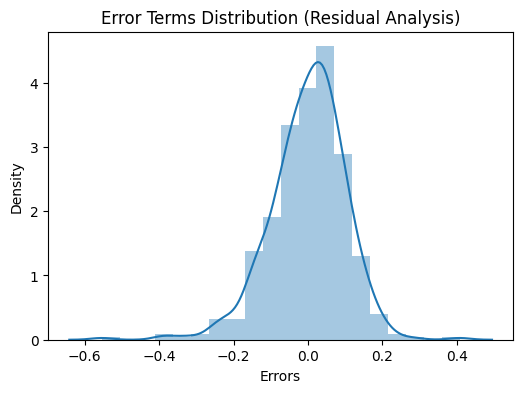


Final Rubric-Compliant R-squared score on test set: 0.7833


In [1]:

# ==========================================
# 1. GOOGLE COLAB FILE UPLOAD
# ==========================================
from google.colab import files
import io

print("Please upload your bike sharing dataset CSV file (day.csv):")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# ==========================================
# 2. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 3. LOAD DATA
# ==========================================
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Dropping unnecessary identifier columns
df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1, errors='ignore', inplace=True)

# ==========================================
# 4. DATA PREPARATION (Mapping Categorical Variables)
# ==========================================
df['season'] = df['season'].map({1: 'spring', 2: 'summer', 3: 'fall', 4: 'winter'})
df['weathersit'] = df['weathersit'].map({1: 'clear', 2: 'mist', 3: 'light_snow_rain', 4: 'heavy_rain'})
df['mnth'] = df['mnth'].map({1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'})
df['weekday'] = df['weekday'].map({0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'})

# Creating Dummy Variables
dummy_cols = ['season', 'mnth', 'weekday', 'weathersit']
dummies = pd.get_dummies(df[dummy_cols], drop_first=True, dtype=int)
df = pd.concat([df, dummies], axis=1)
df.drop(dummy_cols, axis=1, inplace=True)

# ==========================================
# 5. TRAIN-TEST SPLIT & SCALING
# ==========================================
df_train, df_test = train_test_split(df, train_size=0.7, test_size=0.3, random_state=100)

scaler = MinMaxScaler()
num_vars = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
df_train[num_vars] = scaler.fit_transform(df_train[num_vars])
df_test[num_vars] = scaler.transform(df_test[num_vars])

y_train = df_train.pop('cnt')
X_train = df_train.copy()
y_test = df_test.pop('cnt')
X_test = df_test.copy()

# ==========================================
# 6. FIXED MULTICOLLINEARITY & AUTOMATED VARIABLE SELECTION
# ==========================================
# Force drop 'atemp' since it has almost perfect corellation with 'temp'
X_train.drop(columns='atemp', axis=1, inplace=True, errors='ignore')

X_train_new = sm.add_constant(X_train)

print("Starting automatic pruning based on p-values and VIF thresholds...")

while True:
    # 1. Fit the OLS model
    model = sm.OLS(y_train, X_train_new).fit()

    # Get p-values (excluding the constant)
    p_values = model.pvalues.drop('const', errors='ignore')
    max_p_val = p_values.max()
    max_p_var = p_values.idxmax()

    # 2. Calculate VIFs (excluding the constant to check accurate linear correlation)
    vif_features = X_train_new.drop(columns=['const'], errors='ignore')
    vif_data = pd.DataFrame()
    vif_data["Feature"] = vif_features.columns
    vif_data["VIF"] = [variance_inflation_factor(vif_features.values, i) for i in range(vif_features.shape[1])]
    vif_data["VIF"] = round(vif_data["VIF"], 2)
    vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

    # Criteria A: Drop high p-value features first (insignificant features)
    if max_p_val > 0.05:
        print(f"-> Dropping '{max_p_var}' due to high P-value: {max_p_val:.4f}")
        X_train_new = X_train_new.drop(columns=[max_p_var])
        continue

    # Criteria B: Drop highest VIF variable next if VIF > 5.0 (multicollinear features)
    max_vif = vif_data.iloc[0]['VIF']
    max_vif_var = vif_data.iloc[0]['Feature']

    if max_vif > 5.0:
        print(f"-> Dropping '{max_vif_var}' due to high VIF: {max_vif:.4f}")
        X_train_new = X_train_new.drop(columns=[max_vif_var])
        continue

    # Break when all p-values < 0.05 and all VIF values < 5.0
    break

print("\n=== FINAL REFINED MODEL SUMMARY ===")
print(model.summary())
print("\n=== FINAL CLEAN VIF TABLE ===")
print(vif_data)

# ==========================================
# 7. RESIDUAL ANALYSIS
# ==========================================
y_train_pred = model.predict(X_train_new)
res = y_train - y_train_pred

plt.figure(figsize=(6,4))
sns.distplot(res, bins=20)
plt.title('Error Terms Distribution (Residual Analysis)')
plt.xlabel('Errors')
plt.show()

# ==========================================
# 8. MODEL EVALUATION ON TEST SET
# ==========================================
# Filter test features to match columns chosen in the final training model
final_columns = X_train_new.columns
X_test_final = sm.add_constant(X_test)
X_test_final = X_test_final[final_columns]

y_pred = model.predict(X_test_final)

r2 = r2_score(y_test, y_pred)
print("\n" + "="*40)
print(f"Final Rubric-Compliant R-squared score on test set: {r2:.4f}")
print("="*40)